<a href="https://colab.research.google.com/github/Chaitanya15-ai/OIBSIP/blob/main/ChaitanyaSawant_Task3(Sentiment_Analysis).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (32002, 2)

Sentiment Distribution:
category
 1    13569
 0    10941
-1     7492
Name: count, dtype: int64


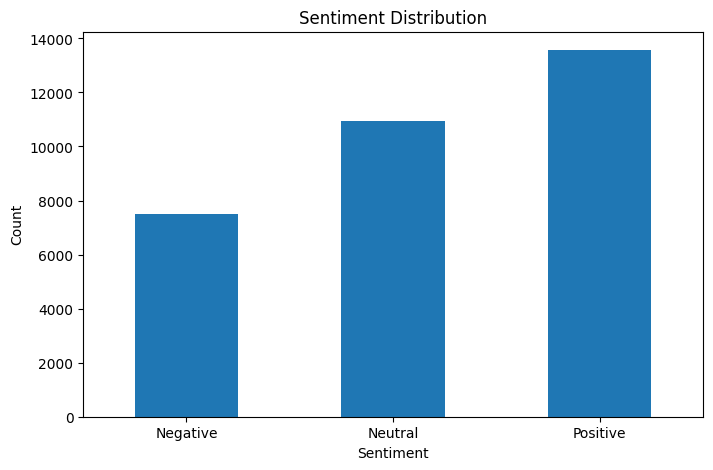

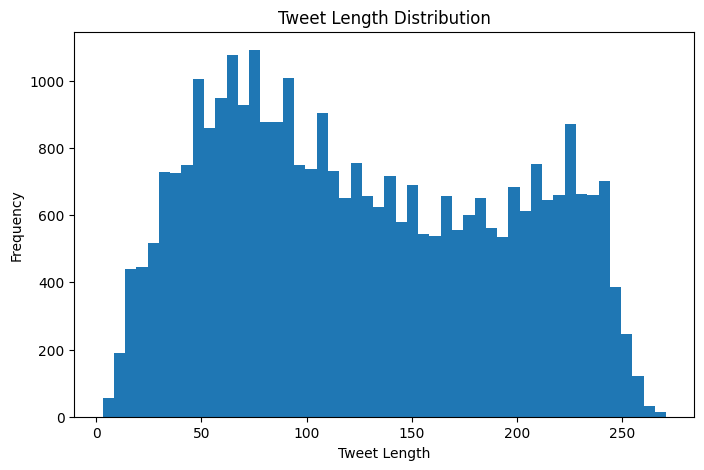


Logistic Regression
Accuracy: 79.96 %

Classification Report:
              precision    recall  f1-score   support

          -1       0.84      0.65      0.73      1477
           0       0.76      0.89      0.82      2180
           1       0.83      0.81      0.82      2744

    accuracy                           0.80      6401
   macro avg       0.81      0.78      0.79      6401
weighted avg       0.80      0.80      0.80      6401


Naive Bayes
Accuracy: 65.6 %

Classification Report:
              precision    recall  f1-score   support

          -1       0.83      0.35      0.49      1477
           0       0.75      0.57      0.65      2180
           1       0.59      0.89      0.71      2744

    accuracy                           0.66      6401
   macro avg       0.73      0.60      0.62      6401
weighted avg       0.70      0.66      0.64      6401


Random Forest
Accuracy: 77.64 %

Classification Report:
              precision    recall  f1-score   support

         

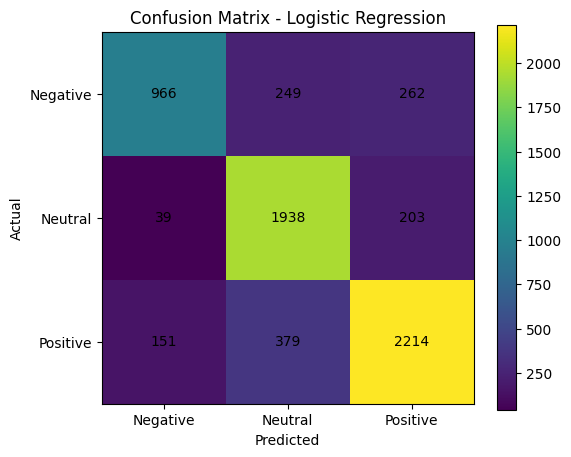

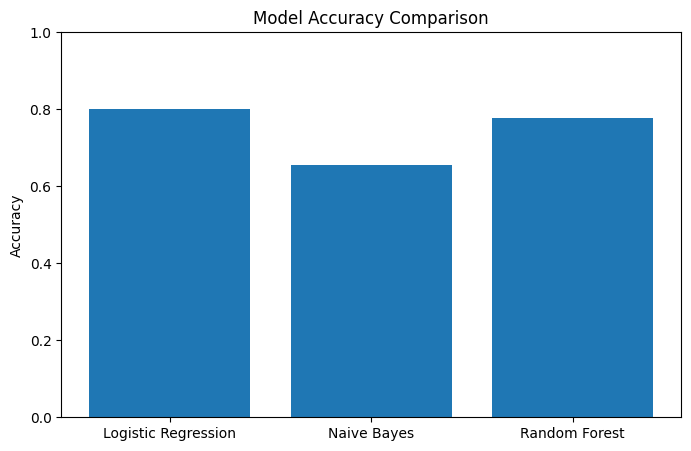

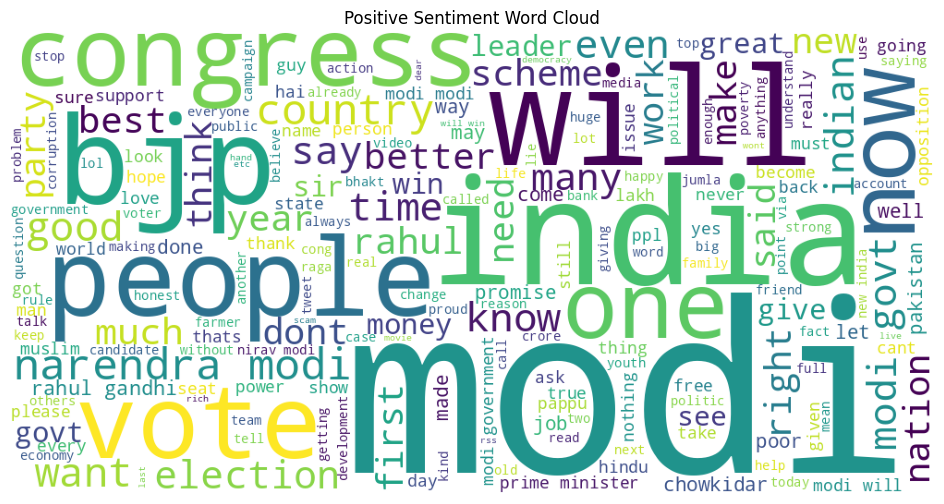

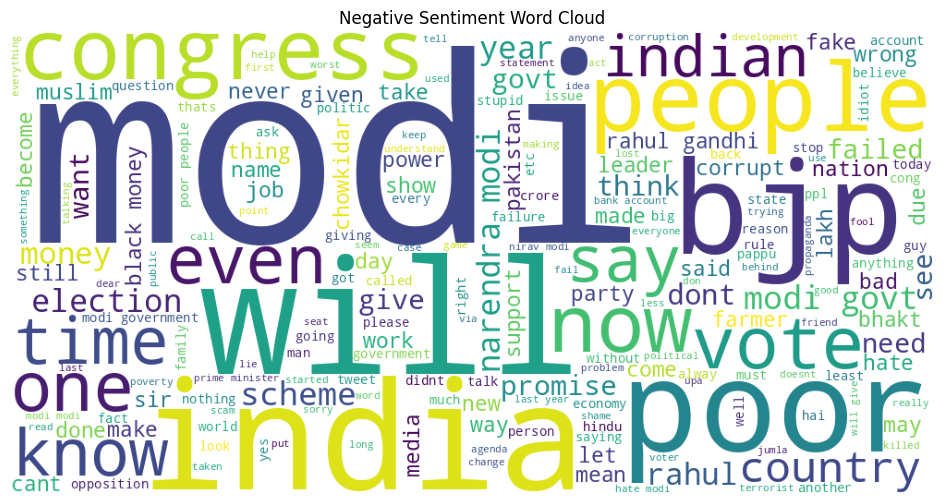


Sample Predictions:
I love this product, it is amazing -> Positive
This is the worst service ever -> Negative
The meeting is scheduled for tomorrow -> Neutral


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("/content/Twitter_Data.csv")

df = df.dropna()
df["category"] = df["category"].astype(int)
df["clean_text"] = df["clean_text"].astype(str)

print("Dataset Shape:", df.shape)
print("\nSentiment Distribution:")
print(df["category"].value_counts())

plt.figure(figsize=(8,5))
df["category"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1,2],["Negative","Neutral","Positive"],rotation=0)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

df["tweet_length"] = df["clean_text"].apply(len)

plt.figure(figsize=(8,5))
plt.hist(df["tweet_length"], bins=50)
plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")
plt.show()

X = df["clean_text"]
y = df["category"]

tfidf = TfidfVectorizer(max_features=10000, stop_words="english")
X = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", round(acc*100,2), "%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Accuracy:", round(best_accuracy*100,2), "%")

best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.colorbar()

plt.xticks([0,1,2],["Negative","Neutral","Positive"])
plt.yticks([0,1,2],["Negative","Neutral","Positive"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

positive_text = " ".join(
    df[df["category"] == 1]["clean_text"]
)

wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_positive)
plt.axis("off")
plt.title("Positive Sentiment Word Cloud")
plt.show()

negative_text = " ".join(
    df[df["category"] == -1]["clean_text"]
)

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_negative)
plt.axis("off")
plt.title("Negative Sentiment Word Cloud")
plt.show()

def predict_sentiment(text):
    vector = tfidf.transform([text])
    prediction = best_model.predict(vector)[0]

    if prediction == 1:
        return "Positive"
    elif prediction == 0:
        return "Neutral"
    else:
        return "Negative"

print("\nSample Predictions:")
print("I love this product, it is amazing ->", predict_sentiment("I love this product, it is amazing"))
print("This is the worst service ever ->", predict_sentiment("This is the worst service ever"))
print("The meeting is scheduled for tomorrow ->", predict_sentiment("The meeting is scheduled for tomorrow"))